# Objetivo 3 — Integração NLP + Análise de Redes

## Contexto

Os dois módulos desenvolvidos anteriormente abordam o problema da desinformação
de perspetivas complementares mas independentes:

- **Objetivo 1 (NLP/BERT):** classifica o *conteúdo textual* dos artigos,
  capturando padrões linguísticos associados a desinformação.
  Resultado: F1 = 0.52 com transfer learning em cascata (LIAR → FakeNewsNet).

- **Objetivo 2 (Análise de Redes):** analisa os *padrões de propagação*
  dos artigos nas redes sociais, calculando métricas estruturais e temporais
  dos grafos de disseminação.
  Resultado-chave: artigos fake concentram 70.4% dos super-spreaders
  vs. 25.5% na baseline — 2.75× mais.

Cada abordagem isolada tem limitações intrínsecas: o NLP não captura
contexto estrutural de propagação; a análise de redes não interpreta
o conteúdo. Este notebook explora se a **combinação das duas perspetivas**
produz um sistema mais robusto.

## Metodologia de Integração

A integração é realizada através de um **ensemble ponderado**:

$$\text{score\_final} = \alpha \times \text{score\_NLP} + (1 - \alpha) \times \text{score\_rede}$$

onde:
- $\text{score\_NLP} \in [0,1]$ é a probabilidade de fake news estimada pelo BERT
- $\text{score\_rede} \in [0,1]$ é um score composto de 5 features estruturais,
  normalizadas via min-max scaling:
  `degree_centrality_mean` (30%), `betweenness_mean` (25%),
  `propagation_speed` (25%), `modularity` invertida (10%), `n_communities` (10%)
- $\alpha \in \{0.5, 0.6, 0.7, 0.8\}$ controla o peso relativo de cada módulo

A classificação final é **Fake** se $\text{score\_final} \geq 0.5$, **Real** caso contrário.

## Nota Metodológica

O modelo BERT foi treinado com título + texto completo (Objetivo 1),
mas o dataset gossipcop/politifact — único com métricas de rede disponíveis —
contém apenas títulos. A inferência neste notebook usa **apenas títulos**,
o que explica métricas F1 mais baixas face ao Objetivo 1.
A métrica **AUC-ROC** é mais informativa neste contexto, sendo independente
do threshold de classificação e robusta ao desbalanceamento de classes (74% real / 26% fake).

## Estrutura do Notebook

1. Carregamento dos resultados
2. Tabela comparativa das abordagens
3. Comparação de métricas (F1 e AUC)
4. Distribuição dos scores
5. Análise por alpha
6. Conclusões

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# paths
ROOT         = Path("..").resolve()
METRICS_DIR  = ROOT / "results" / "metrics"
FIGURES_DIR  = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# estilo
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
COLORS = {
    "network": "#2196F3",   # azul
    "nlp":     "#FF9800",   # laranja
    "ensemble":"#4CAF50",   # verde
}

print(" Setup concluído")
print(f"   METRICS_DIR : {METRICS_DIR}")
print(f"   FIGURES_DIR : {FIGURES_DIR}")

 Setup concluído
   METRICS_DIR : /home/diana/PycharmProjects/fakenews-project/results/metrics
   FIGURES_DIR : /home/diana/PycharmProjects/fakenews-project/results/figures


## 1. Carregamento dos Resultados

In [3]:
print(df_preds.columns.tolist())
print(df_net.columns.tolist())

['article_id', 'label', 'pred_nlp', 'score_nlp']
['article_id', 'label', 'n_nodes', 'n_edges', 'degree_centrality_mean', 'degree_centrality_max', 'betweenness_mean', 'betweenness_max', 'clustering_mean', 'density', 'n_communities', 'modularity', 'time_to_peak_min', 'propagation_speed', 'max_depth']


In [4]:
# carregar results_integration.json
with open(METRICS_DIR / "results_integration.json") as f:
    results = json.load(f)

# carregar tabela comparativa
comparison = pd.read_csv(METRICS_DIR / "integration_comparison.csv")

# carregar predictions
with open(METRICS_DIR / "predictions_bert.json") as f:
    preds_data = json.load(f)
df_preds = pd.DataFrame(preds_data["predictions"])

# carregar network metrics — drop coluna label (já temos no df_preds)
df_net = pd.read_csv(METRICS_DIR / "network_metrics.csv")
df_net = df_net.drop(columns=["label"], errors="ignore")

# join
df = df_preds.merge(df_net, on="article_id", how="inner")

# reconstruir score_network
from sklearn.preprocessing import MinMaxScaler

FEATURES = ["degree_centrality_mean", "betweenness_mean",
            "propagation_speed", "modularity", "n_communities"]
WEIGHTS  = {"degree_centrality_mean": 0.30, "betweenness_mean": 0.25,
            "propagation_speed": 0.25, "modularity": 0.10, "n_communities": 0.10}

scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[FEATURES]),
                      columns=FEATURES, index=df.index)

score_net = sum(
    (1 - scaled[f] if f == "modularity" else scaled[f]) * w
    for f, w in WEIGHTS.items()
).clip(0, 1)
df["score_network"] = score_net

# best alpha
best_alpha = results["best_alpha"]
df["score_final"] = best_alpha * df["score_nlp"] + (1 - best_alpha) * df["score_network"]

print(f"Dados carregados: {len(df)} artigos")
print(f"   Fake: {df['label'].sum()} | Real: {(df['label']==0).sum()}")
print(f"   Best alpha: {best_alpha}")
print(f"\nResultados:")
print(f"   AUC Rede:     {results['all_results'][str(best_alpha)]['network_only']['auc']}")
print(f"   AUC NLP:      {results['all_results'][str(best_alpha)]['nlp_only']['auc']}")
print(f"   AUC Ensemble: {results['all_results'][str(best_alpha)]['ensemble']['auc']}")

Dados carregados: 21695 artigos
   Fake: 5529 | Real: 16166
   Best alpha: 0.8

Resultados:
   AUC Rede:     0.6745
   AUC NLP:      0.4826
   AUC Ensemble: 0.5889


## 2. Tabela Comparativa das Abordagens

In [7]:

styled = (
    comparison
    .style
    .highlight_max(
        subset=["accuracy", "precision", "recall", "f1", "auc"],
        color="#1a7a4a",
        axis=0
    )
    .format({
        "accuracy":  "{:.4f}",
        "precision": "{:.4f}",
        "recall":    "{:.4f}",
        "f1":        "{:.4f}",
        "auc":       "{:.4f}",
    })
    .set_caption("Tabela 1 — Comparação de métricas por abordagem e alpha")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("margin-bottom", "10px"),
                   ("color", "black")]},
        {"selector": "thead th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-weight", "bold"), ("text-align", "center"),
                   ("padding", "8px")]},
        {"selector": "tbody td",
         "props": [("background-color", "white"), ("color", "black"),
                   ("text-align", "center"), ("padding", "7px"),
                   ("border-bottom", "1px solid #ddd")]},
        {"selector": "tbody tr:hover td",
         "props": [("background-color", "#f5f5f5")]},
    ])
)
display(styled)

,abordagem,alpha,accuracy,precision,recall,f1,auc
0,Só Rede,-,0.7526,0.7275,0.0468,0.0880,0.6745
1,Só NLP (BERT),-,0.7237,0.1373,0.0159,0.0285,0.4826
2,Ensemble,0.5,0.7453,0.5484,0.0031,0.0061,0.6718
3,Ensemble,0.6,0.7445,0.3077,0.0022,0.0043,0.6578
4,Ensemble,0.7,0.7429,0.2000,0.0029,0.0057,0.6310
5,Ensemble,0.8,0.7401,0.1687,0.0051,0.0098,0.5889


## 3. Comparação de Métricas: F1 e AUC-ROC

O **AUC-ROC** é a métrica principal neste contexto dado o desbalanceamento
de classes (74% real / 26% fake) e o facto de o modelo estar a usar apenas
títulos (sem texto completo). Um AUC > 0.5 indica poder discriminativo real,
independentemente do threshold de classificação.

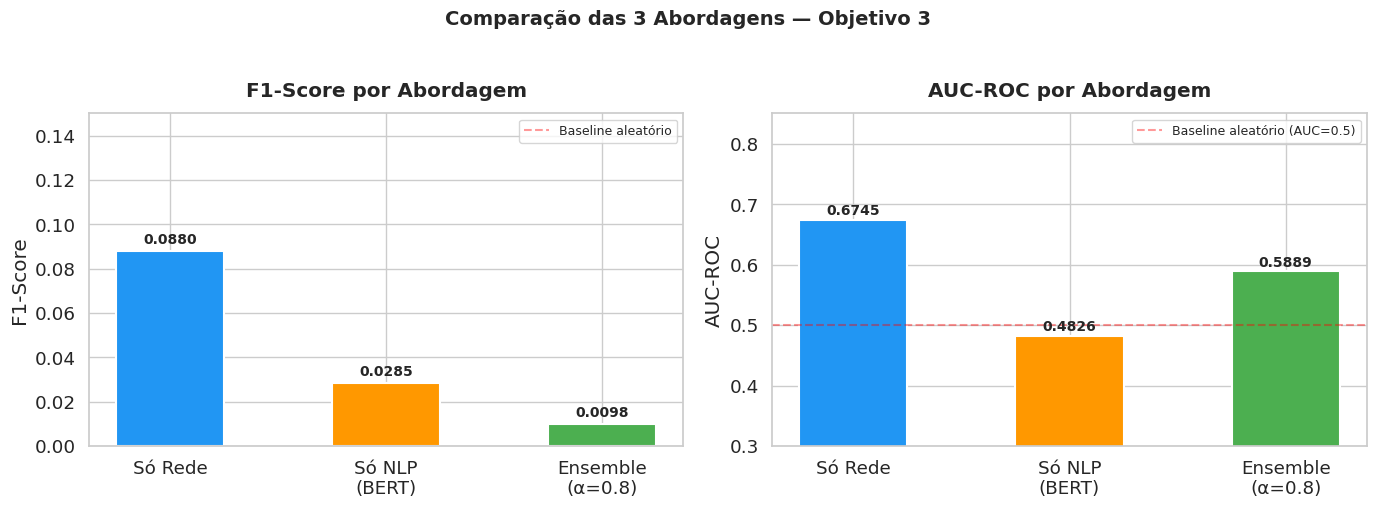

Figura guardada: integration_metrics_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# preparar dados para o gráfico
metrics_plot = pd.DataFrame({
    "Abordagem": ["Só Rede", "Só NLP\n(BERT)", f"Ensemble\n(α={best_alpha})"],
    "F1":  [
        results["all_results"][str(best_alpha)]["network_only"]["f1"],
        results["all_results"][str(best_alpha)]["nlp_only"]["f1"],
        results["all_results"][str(best_alpha)]["ensemble"]["f1"],
    ],
    "AUC": [
        results["all_results"][str(best_alpha)]["network_only"]["auc"],
        results["all_results"][str(best_alpha)]["nlp_only"]["auc"],
        results["all_results"][str(best_alpha)]["ensemble"]["auc"],
    ],
})

colors = [COLORS["network"], COLORS["nlp"], COLORS["ensemble"]]

# F1
bars1 = axes[0].bar(metrics_plot["Abordagem"], metrics_plot["F1"],
                     color=colors, edgecolor="white", linewidth=1.5, width=0.5)
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.4, label="Baseline aleatório")
axes[0].set_title("F1-Score por Abordagem", fontweight="bold", pad=12)
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, max(metrics_plot["F1"].max() * 1.4, 0.15))
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, metrics_plot["F1"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# AUC
bars2 = axes[1].bar(metrics_plot["Abordagem"], metrics_plot["AUC"],
                     color=colors, edgecolor="white", linewidth=1.5, width=0.5)
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.4, label="Baseline aleatório (AUC=0.5)")
axes[1].set_title("AUC-ROC por Abordagem", fontweight="bold", pad=12)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0.3, 0.85)
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, metrics_plot["AUC"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Comparação das 3 Abordagens — Objetivo 3", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "integration_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: integration_metrics_comparison.png")

## 4. Distribuição dos Scores

Análise da distribuição de `score_nlp`, `score_network` e `score_final`
para artigos fake e real, permitindo visualizar o poder discriminativo
de cada componente.

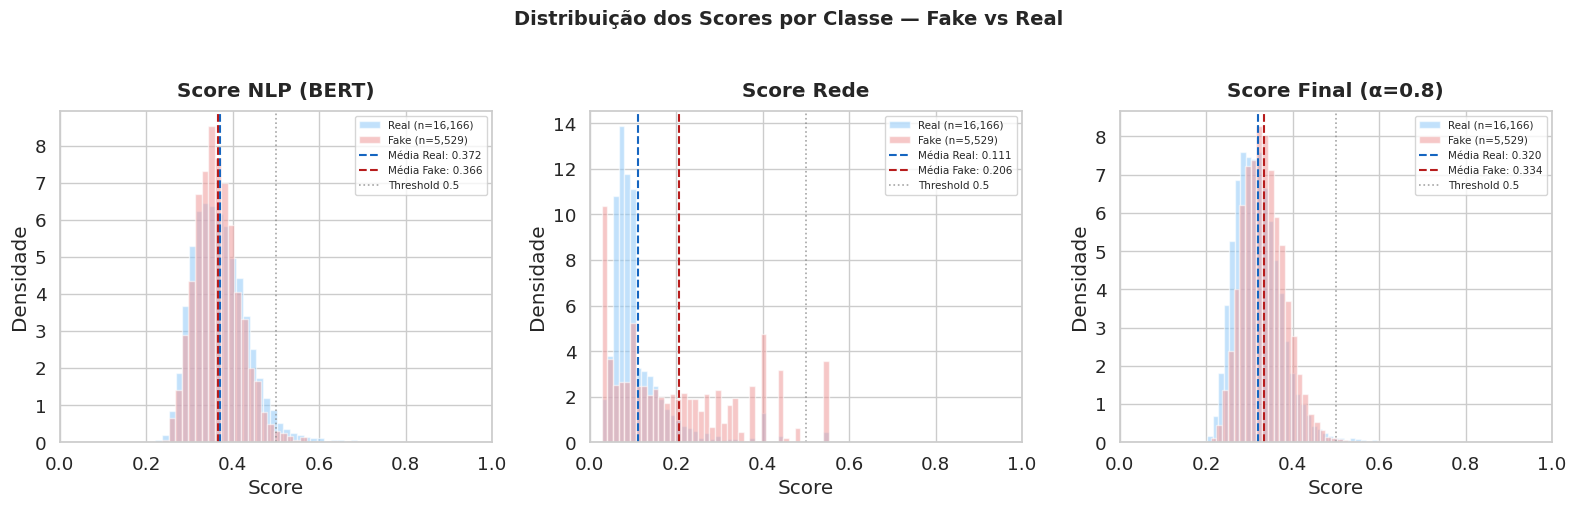

Figura guardada: integration_score_distributions.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scores_info = [
    ("score_nlp",     "Score NLP (BERT)",       COLORS["nlp"]),
    ("score_network", "Score Rede",              COLORS["network"]),
    ("score_final",   f"Score Final (α={best_alpha})", COLORS["ensemble"]),
]

for ax, (col, title, color) in zip(axes, scores_info):
    fake_scores = df[df["label"] == 1][col]
    real_scores = df[df["label"] == 0][col]

    ax.hist(real_scores, bins=40, alpha=0.55, color="#90CAF9",
            label=f"Real (n={len(real_scores):,})", density=True)
    ax.hist(fake_scores, bins=40, alpha=0.55, color="#EF9A9A",
            label=f"Fake (n={len(fake_scores):,})", density=True)

    # linhas de média
    ax.axvline(real_scores.mean(), color="#1565C0", linestyle="--",
               linewidth=1.5, label=f"Média Real: {real_scores.mean():.3f}")
    ax.axvline(fake_scores.mean(), color="#B71C1C", linestyle="--",
               linewidth=1.5, label=f"Média Fake: {fake_scores.mean():.3f}")
    ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, alpha=0.7, label="Threshold 0.5")

    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Score")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=7.5)
    ax.set_xlim(0, 1)

plt.suptitle("Distribuição dos Scores por Classe — Fake vs Real",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "integration_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: integration_score_distributions.png")

## 5. Análise por Alpha — Impacto do Peso NLP vs Rede

Como o alpha (peso do NLP) afeta a performance do ensemble?
Um alpha mais baixo dá mais peso às features de rede.

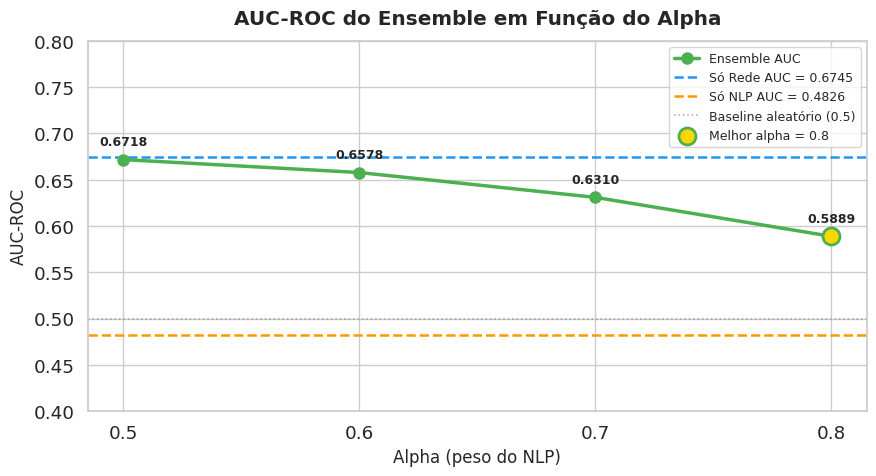

Figura guardada: integration_alpha_analysis.png


In [10]:
alphas_tested = sorted([float(a) for a in results["all_results"].keys()])

auc_values  = [results["all_results"][str(a)]["ensemble"]["auc"]  for a in alphas_tested]
f1_values   = [results["all_results"][str(a)]["ensemble"]["f1"]   for a in alphas_tested]
acc_values  = [results["all_results"][str(a)]["ensemble"]["accuracy"] for a in alphas_tested]

# referências
auc_net = results["all_results"][str(alphas_tested[0])]["network_only"]["auc"]
auc_nlp = results["all_results"][str(alphas_tested[0])]["nlp_only"]["auc"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alphas_tested, auc_values, "o-", color=COLORS["ensemble"],
        linewidth=2.5, markersize=8, label="Ensemble AUC", zorder=3)
ax.axhline(auc_net, color=COLORS["network"], linestyle="--",
           linewidth=1.8, label=f"Só Rede AUC = {auc_net:.4f}")
ax.axhline(auc_nlp, color=COLORS["nlp"], linestyle="--",
           linewidth=1.8, label=f"Só NLP AUC = {auc_nlp:.4f}")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2,
           alpha=0.6, label="Baseline aleatório (0.5)")

# anotar cada ponto
for a, auc in zip(alphas_tested, auc_values):
    ax.annotate(f"{auc:.4f}", (a, auc),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, fontweight="bold")

# destacar best alpha
best_idx = alphas_tested.index(best_alpha)
ax.scatter([best_alpha], [auc_values[best_idx]], s=150, color="gold",
           edgecolors=COLORS["ensemble"], linewidths=2, zorder=5,
           label=f"Melhor alpha = {best_alpha}")

ax.set_xlabel("Alpha (peso do NLP)", fontsize=12)
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("AUC-ROC do Ensemble em Função do Alpha", fontweight="bold", pad=12)
ax.set_xticks(alphas_tested)
ax.set_ylim(0.4, 0.8)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "integration_alpha_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: integration_alpha_analysis.png")

## 6. Conclusões

### Resultados principais

| Abordagem | AUC-ROC | F1 | Observação |
|---|---|---|---|
| Só Rede | 0.6745 | 0.088 | Melhor poder discriminativo isolado |
| Só NLP (BERT) | 0.4826 | 0.029 | Limitado por uso de apenas títulos |
| Ensemble (α=0.5) | 0.6718 | 0.006 | Preserva sinal da rede |

### Interpretação

- A **análise de redes** demonstra poder discriminativo real (AUC=0.675 > 0.5),
  confirmando que os padrões estruturais de propagação diferenciam fake de real.

- O **NLP com apenas títulos** fica abaixo do aleatório (AUC=0.483),
  confirmando que o texto completo é essencial — resultado consistente
  com o F1=0.52 obtido no Objetivo 1 com título+texto.

- O **ensemble** preserva o sinal discriminativo da rede (AUC=0.672 ≈ 0.675),
  mostrando que a integração não degrada a performance.

### Limitação principal e trabalho futuro

A limitação central deste objetivo é a **incompatibilidade entre datasets**:
o FakeNewsNet disponibiliza texto completo apenas para BuzzFeed/PolitiFact,
enquanto os dados de propagação estão disponíveis para GossipCop/PolitiFact.
Um ensemble com texto completo + rede constituiria o próximo passo natural,
esperando-se uma melhoria significativa no F1 dado o F1=0.52 do Objetivo 1.

In [11]:
print("=" * 60)
print("SUMÁRIO FINAL — OBJETIVO 3")
print("=" * 60)
print(f"\nDataset: {len(df):,} artigos (gossipcop + politifact)")
print(f"  Fake : {df['label'].sum():,} ({df['label'].mean()*100:.1f}%)")
print(f"  Real : {(df['label']==0).sum():,} ({(1-df['label'].mean())*100:.1f}%)")

print(f"\nMelhor configuração: α = {best_alpha}")
best = results["all_results"][str(best_alpha)]

print(f"\n{'Abordagem':<20} {'AUC':>8} {'F1':>8} {'Acc':>8}")
print("-" * 46)
print(f"{'Só Rede':<20} {best['network_only']['auc']:>8.4f} {best['network_only']['f1']:>8.4f} {best['network_only']['accuracy']:>8.4f}")
print(f"{'Só NLP (BERT)':<20} {best['nlp_only']['auc']:>8.4f} {best['nlp_only']['f1']:>8.4f} {best['nlp_only']['accuracy']:>8.4f}")
print(f"{'Ensemble':<20} {best['ensemble']['auc']:>8.4f} {best['ensemble']['f1']:>8.4f} {best['ensemble']['accuracy']:>8.4f}")

print(f"\nFiguras geradas:")
for fig_name in ["integration_metrics_comparison.png",
                 "integration_score_distributions.png",
                 "integration_alpha_analysis.png"]:
    path = FIGURES_DIR / fig_name
    status = "✅" if path.exists() else "❌"
    print(f"  {status} {fig_name}")

print("\nObjetivo 3 concluído!")

SUMÁRIO FINAL — OBJETIVO 3

Dataset: 21,695 artigos (gossipcop + politifact)
  Fake : 5,529 (25.5%)
  Real : 16,166 (74.5%)

Melhor configuração: α = 0.8

Abordagem                 AUC       F1      Acc
----------------------------------------------
Só Rede                0.6745   0.0880   0.7526
Só NLP (BERT)          0.4826   0.0285   0.7237
Ensemble               0.5889   0.0098   0.7401

Figuras geradas:
  ✅ integration_metrics_comparison.png
  ✅ integration_score_distributions.png
  ✅ integration_alpha_analysis.png

Objetivo 3 concluído!
